<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/Section_7_AR_SecondOrder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.arima_model import ARMA
from scipy.stats.distributions import chi2
import statsmodels.tsa.stattools as sts
import seaborn as sns
sns.set()

In [3]:
raw_csv_data = pd.read_csv("/content/sample_data/SecondOrder.csv", sep=';') #read directly from Pandas library
df_comp=raw_csv_data.copy()
df_comp.Time = pd.to_datetime(df_comp.Time, dayfirst = True)
df_comp.set_index("Time", inplace=True)
df_comp=df_comp.asfreq('d')
df_comp=df_comp.fillna(method='ffill')

/tmp/ipython-input-440051709.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_comp=df_comp.fillna(method='ffill')


In [5]:
df_comp.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6000 entries, 2010-01-01 to 2026-06-05
Freq: D
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   s2_0s_1_NoNoise      6000 non-null   float64
 1   s2_0s_1_001Noise     6000 non-null   float64
 2   s2_0s_1_0001Noise    6000 non-null   float64
 3   s2_0s_1_00001Noise   6000 non-null   float64
 4   s2_01s_1_NoNoise     6000 non-null   float64
 5   s2_01s_1_001Noise    6000 non-null   float64
 6   s2_01s_1_0001Noise   6000 non-null   float64
 7   s2_01s_1_00001Noise  6000 non-null   float64
dtypes: float64(8)
memory usage: 421.9 KB


In [6]:
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

In [34]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# df: your train part (DatetimeIndex) with 8 columns
# Make sure index is datetime (it is in your screenshot)
# df.index = pd.to_datetime(df.index)

cols = list(df.columns)  # all columns in the DataFrame
n = len(cols)

# --- one column per row (stacked), shared time axis ---
fig = make_subplots(
    rows=n, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.02,
    subplot_titles=cols
)

for i, c in enumerate(cols, start=1):
    fig.add_trace(
        go.Scatter(
            x=df.index, y=df[c],
            mode="lines",
            name=c,
            hovertemplate="Time=%{x}<br>Value=%{y:.6f}<extra></extra>"
        ),
        row=i, col=1
    )
    fig.update_yaxes(title_text=c, row=i, col=1)  # label each subplot y-axis

fig.update_layout(
    template="plotly_dark",
    title="Time Series (each column stacked)",
    height=max(900, 180 * n),          # auto scale height with number of rows
    showlegend=False,
    hovermode="x unified",
    margin=dict(t=70, b=40, l=70, r=30)
)

fig.update_xaxes(title_text="Time", row=n, col=1)  # label x-axis only at the bottom
fig.show()


ACF - for full period

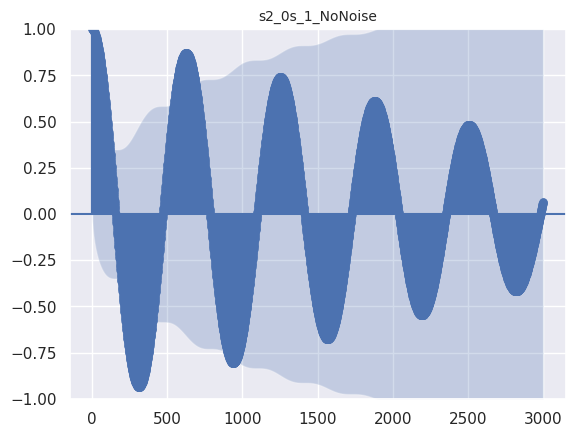

In [20]:
sgt.plot_acf(df.s2_0s_1_NoNoise, zero = False, lags = 3000)
plt.title("s2_0s_1_NoNoise", size = 10)
plt.show()

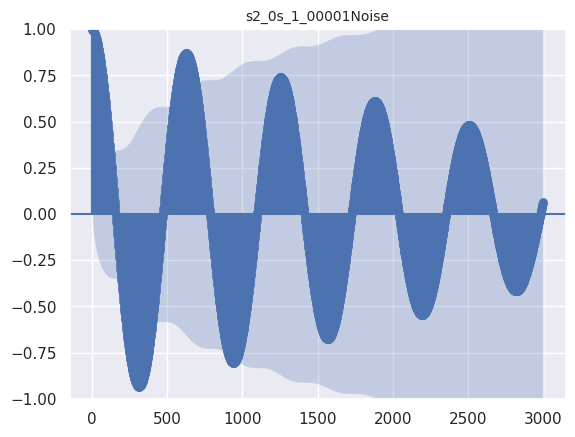

In [19]:
sgt.plot_acf(df.s2_0s_1_00001Noise, zero = False, lags = 3000)
plt.title("s2_0s_1_00001Noise", size = 10)
plt.show()

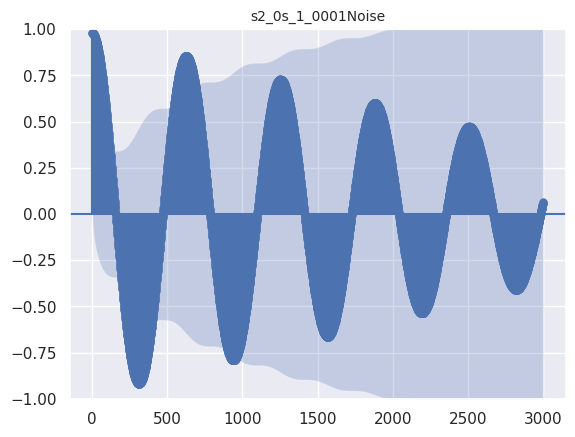

In [18]:
sgt.plot_acf(df.s2_0s_1_0001Noise, zero = False, lags = 3000)
plt.title("s2_0s_1_0001Noise", size = 10)
plt.show()

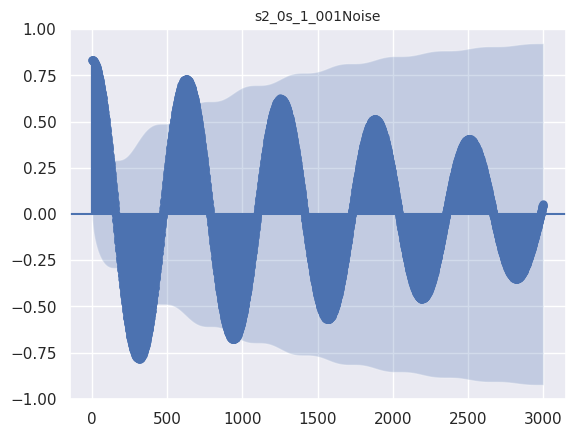

In [17]:
sgt.plot_acf(df.s2_0s_1_001Noise, zero = False, lags = 3000)
plt.title("s2_0s_1_001Noise", size = 10)
plt.show()

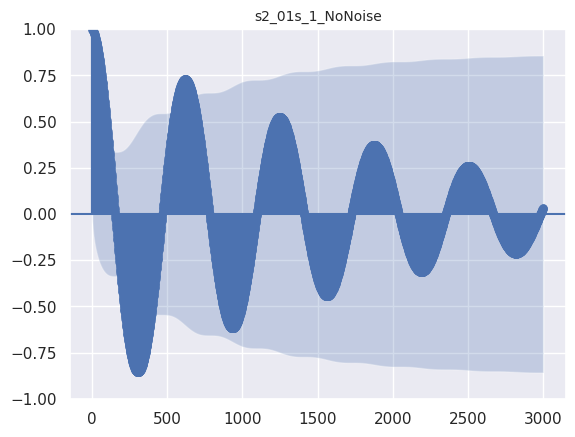

In [16]:
sgt.plot_acf(df.s2_01s_1_NoNoise, zero = False, lags = 3000)
plt.title("s2_01s_1_NoNoise", size = 10)
plt.show()

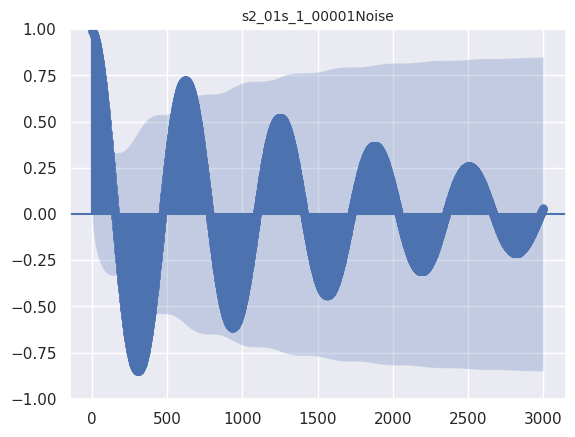

In [21]:
sgt.plot_acf(df.s2_01s_1_00001Noise, zero = False, lags = 3000)
plt.title("s2_01s_1_00001Noise", size = 10)
plt.show()

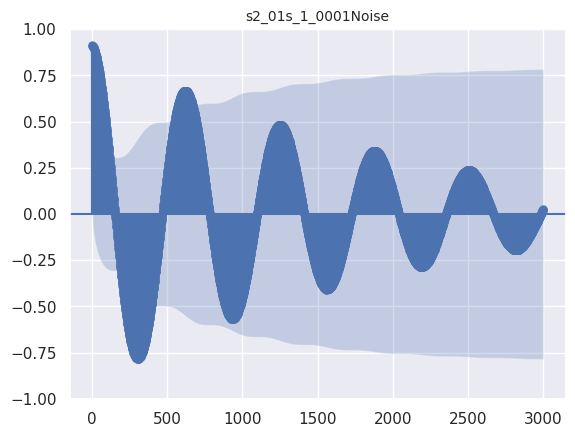

In [22]:
sgt.plot_acf(df.s2_01s_1_0001Noise, zero = False, lags = 3000)
plt.title("s2_01s_1_0001Noise", size = 10)
plt.show()

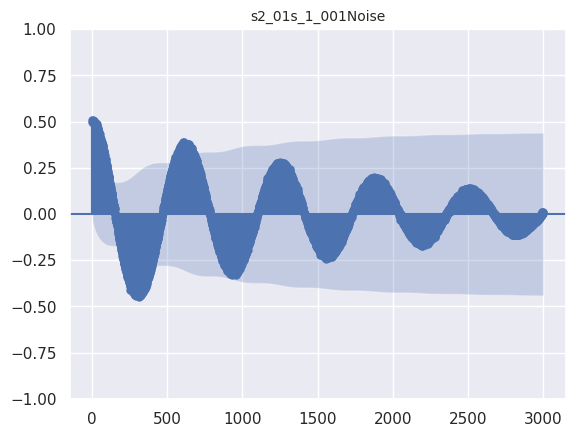

In [23]:
sgt.plot_acf(df.s2_01s_1_001Noise, zero = False, lags = 3000)
plt.title("s2_01s_1_001Noise", size = 10)
plt.show()

ACF - SHORT TERM

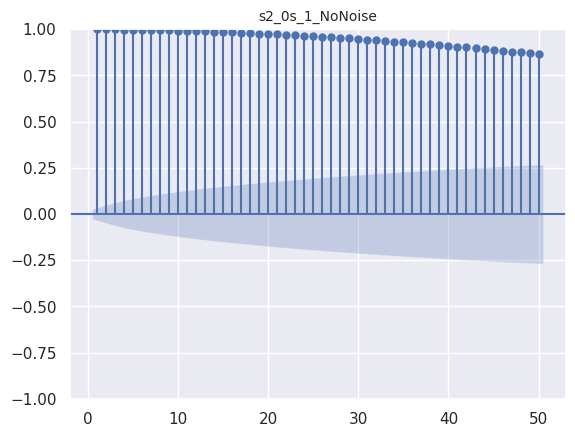

In [24]:
#best
sgt.plot_acf(df.s2_0s_1_NoNoise, zero = False, lags = 50)
plt.title("s2_0s_1_NoNoise", size = 10)
plt.show()

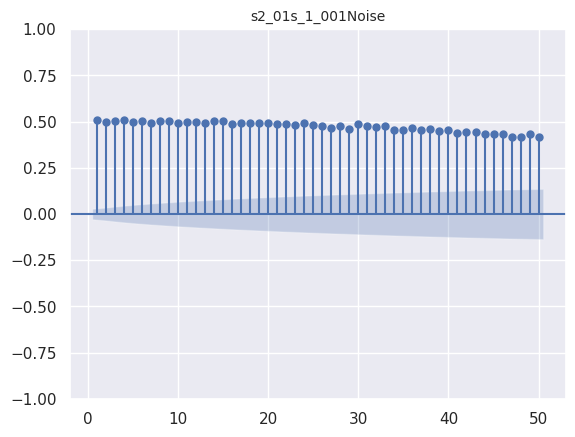

In [25]:
#worst
sgt.plot_acf(df.s2_01s_1_001Noise, zero = False, lags = 50)
plt.title("s2_01s_1_001Noise", size = 10)
plt.show()

PACF

Which do we use to select the correct AR model and why: the ACF or the PACF?

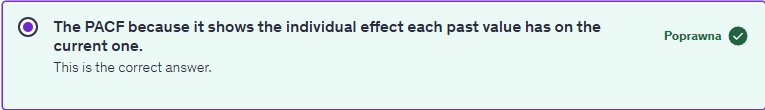

To jest jakby wizualizacja transformaty Z

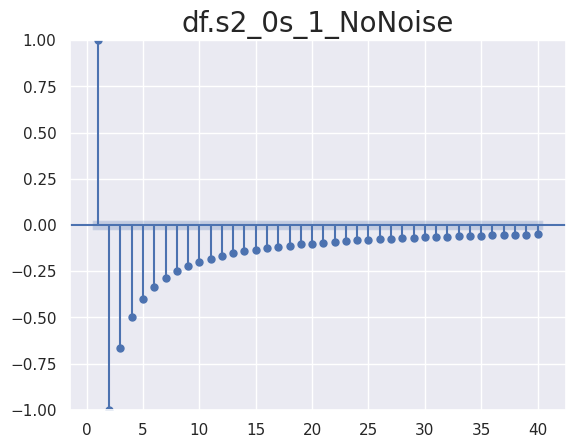

In [33]:
sgt.plot_pacf(df.s2_0s_1_NoNoise, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("df.s2_0s_1_NoNoise", size = 20)
plt.show()

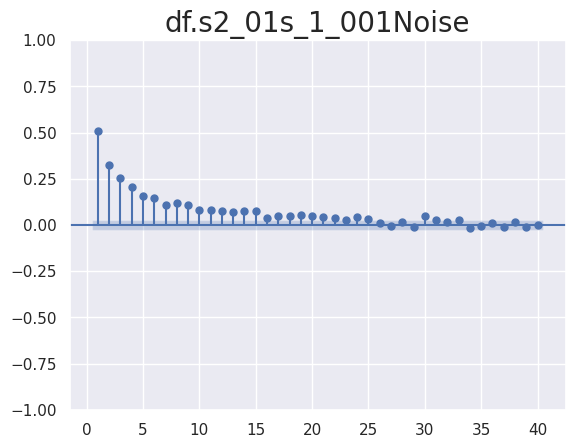

In [28]:
sgt.plot_pacf(df.s2_01s_1_001Noise, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("df.s2_01s_1_001Noise", size = 20)
plt.show()

#AR(1) Model

1 #best

In [39]:
from statsmodels.tsa.arima.model import ARIMA

model_ar1 = ARIMA(df.s2_0s_1_NoNoise, order=(1,0,0))

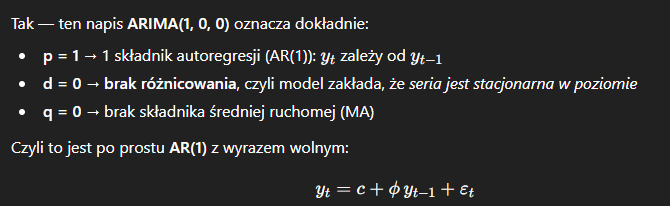

In [40]:
results_ar1 = model_ar.fit()

In [41]:
results_ar1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      s2_01s_1_001Noise   No. Observations:                 4800
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2251.583
Date:                Sun, 04 Jan 2026   AIC                           4509.167
Time:                        12:19:42   BIC                           4528.596
Sample:                    01-01-2010   HQIC                          4515.990
                         - 02-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0046      0.011     88.132      0.000       0.982       1.027
ar.L1          0.5101      0.012     42.141      0.000       0.486       0.534
sigma2         0.1496      0.003     49.583      0.000       0.144       0.156
===================================================================================
Ljung-Box (L1) (Q):                 130.38   Jarque-Bera (JB):                 2.60
Prob(Q):                              0.00   Prob(JB):                         0.27
Heteroskedasticity (H):               0.68   Skew:                             0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

xt=1.0046 + 0.5101(xt-1) + epsilon niżej

In [45]:
# epsilon_t = residuals / innovations (time series)
eps = results_ar1.resid          # pandas Series aligned to your index (same timeline)
eps.head(), eps.describe()

(Time
 2010-01-01   -0.891825
 2010-01-02    0.205164
 2010-01-03   -1.148084
 2010-01-04    0.053022
 2010-01-05   -0.636836
 Freq: D, dtype: float64,
 count    4800.000000
 mean        0.000098
 std         0.386880
 min        -1.259949
 25%        -0.258362
 50%        -0.003030
 75%         0.256296
 max         1.632417
 dtype: float64)

2 # worst

In [42]:
from statsmodels.tsa.arima.model import ARIMA

model_ar2 = ARIMA(df.s2_01s_1_001Noise, order=(1,0,0))

In [43]:
results_ar2 = model_ar.fit()

In [44]:
results_ar2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      s2_01s_1_001Noise   No. Observations:                 4800
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2251.583
Date:                Sun, 04 Jan 2026   AIC                           4509.167
Time:                        12:20:08   BIC                           4528.596
Sample:                    01-01-2010   HQIC                          4515.990
                         - 02-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0046      0.011     88.132      0.000       0.982       1.027
ar.L1          0.5101      0.012     42.141      0.000       0.486       0.534
sigma2         0.1496      0.003     49.583      0.000       0.144       0.156
===================================================================================
Ljung-Box (L1) (Q):                 130.38   Jarque-Bera (JB):                 2.60
Prob(Q):                              0.00   Prob(JB):                         0.27
Heteroskedasticity (H):               0.68   Skew:                             0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

xt=1.0046 + 0.5101(xt-1) + epsilon niżej

In [46]:
# epsilon_t = residuals / innovations (time series)
eps = results_ar2.resid          # pandas Series aligned to your index (same timeline)
eps.head(), eps.describe()

(Time
 2010-01-01   -0.891825
 2010-01-02    0.205164
 2010-01-03   -1.148084
 2010-01-04    0.053022
 2010-01-05   -0.636836
 Freq: D, dtype: float64,
 count    4800.000000
 mean        0.000098
 std         0.386880
 min        -1.259949
 25%        -0.258362
 50%        -0.003030
 75%         0.256296
 max         1.632417
 dtype: float64)

#AR(n) Models

best

In [66]:
from statsmodels.tsa.arima.model import ARIMA

model_ar_21 = ARIMA(df.s2_0s_1_NoNoise, order=(2,0,0))
results_ar_21 = model_ar_21.fit()
results_ar_21.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        s2_0s_1_NoNoise   No. Observations:                 4800
Model:                 ARIMA(2, 0, 0)   Log Likelihood               50764.415
Date:                Sun, 04 Jan 2026   AIC                        -101520.830
Time:                        13:02:17   BIC                        -101494.924
Sample:                    01-01-2010   HQIC                       -101511.731
                         - 02-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0158   5.16e-11   1.97e+10      0.000       1.016       1.016
ar.L1          1.9999   1.53e-06   1.31e+06      0.000       2.000       2.000
ar.L2         -1.0000   1.02e-06  -9.78e+05      0.000      -1.000      -1.000
sigma2          1e-10   2.86e-11      3.492      0.000    4.39e-11    1.56e-10
===================================================================================
Ljung-Box (L1) (Q):                   1.98   Jarque-Bera (JB):        4340837905.76
Prob(Q):                              0.16   Prob(JB):                         0.00
Heteroskedasticity (H):               0.64   Skew:                           -67.76
Prob(H) (two-sided):                  0.00   Kurtosis:                      4659.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.35e+19. Standard errors may be unstable.
"""

worst

In [51]:
from statsmodels.tsa.arima.model import ARIMA

model_ar_22 = ARIMA(df.s2_01s_1_001Noise, order=(2,0,0))
results_ar_22 = model_ar_22.fit()
results_ar_22.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      s2_01s_1_001Noise   No. Observations:                 4800
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1988.216
Date:                Sun, 04 Jan 2026   AIC                           3984.431
Time:                        12:46:39   BIC                           4010.337
Sample:                    01-01-2010   HQIC                          3993.530
                         - 02-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0044      0.016     63.130      0.000       0.973       1.036
ar.L1          0.3456      0.014     25.299      0.000       0.319       0.372
ar.L2          0.3225      0.014     23.381      0.000       0.295       0.350
sigma2         0.1340      0.003     48.955      0.000       0.129       0.139
===================================================================================
Ljung-Box (L1) (Q):                  32.18   Jarque-Bera (JB):                 2.74
Prob(Q):                              0.00   Prob(JB):                         0.25
Heteroskedasticity (H):               0.81   Skew:                             0.06
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
from statsmodels.tsa.arima.model import ARIMA

model_ar_23 = ARIMA(df.s2_01s_1_001Noise, order=(3,0,0))
results_ar_23 = model_ar_23.fit()
results_ar_23.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      s2_01s_1_001Noise   No. Observations:                 4800
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1829.337
Date:                Sun, 04 Jan 2026   AIC                           3668.674
Time:                        12:46:50   BIC                           3701.056
Sample:                    01-01-2010   HQIC                          3680.047
                         - 02-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0040      0.021     48.783      0.000       0.964       1.044
ar.L1          0.2642      0.014     18.911      0.000       0.237       0.292
ar.L2          0.2349      0.014     16.469      0.000       0.207       0.263
ar.L3          0.2533      0.014     18.015      0.000       0.226       0.281
sigma2         0.1255      0.003     48.740      0.000       0.120       0.130
===================================================================================
Ljung-Box (L1) (Q):                  13.30   Jarque-Bera (JB):                 2.01
Prob(Q):                              0.00   Prob(JB):                         0.37
Heteroskedasticity (H):               0.87   Skew:                             0.05
Prob(H) (two-sided):                  0.01   Kurtosis:                         2.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [53]:
from statsmodels.tsa.arima.model import ARIMA

model_ar_24 = ARIMA(df.s2_01s_1_001Noise, order=(4,0,0))
results_ar_24 = model_ar_24.fit()
results_ar_24.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      s2_01s_1_001Noise   No. Observations:                 4800
Model:                 ARIMA(4, 0, 0)   Log Likelihood               -1725.290
Date:                Sun, 04 Jan 2026   AIC                           3462.579
Time:                        12:47:14   BIC                           3501.437
Sample:                    01-01-2010   HQIC                          3476.226
                         - 02-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0035      0.025     39.628      0.000       0.954       1.053
ar.L1          0.2121      0.014     14.998      0.000       0.184       0.240
ar.L2          0.1866      0.014     12.910      0.000       0.158       0.215
ar.L3          0.1988      0.014     13.939      0.000       0.171       0.227
ar.L4          0.2061      0.014     14.627      0.000       0.179       0.234
sigma2         0.1201      0.002     48.928      0.000       0.115       0.125
===================================================================================
Ljung-Box (L1) (Q):                   5.07   Jarque-Bera (JB):                 1.45
Prob(Q):                              0.02   Prob(JB):                         0.49
Heteroskedasticity (H):               0.91   Skew:                             0.04
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [54]:
from statsmodels.tsa.arima.model import ARIMA

model_ar_25 = ARIMA(df.s2_01s_1_001Noise, order=(5,0,0))
results_ar_25 = model_ar_25.fit()
results_ar_25.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      s2_01s_1_001Noise   No. Observations:                 4800
Model:                 ARIMA(5, 0, 0)   Log Likelihood               -1666.601
Date:                Sun, 04 Jan 2026   AIC                           3347.203
Time:                        12:52:21   BIC                           3392.537
Sample:                    01-01-2010   HQIC                          3363.125
                         - 02-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0028      0.030     33.907      0.000       0.945       1.061
ar.L1          0.1800      0.015     12.386      0.000       0.152       0.209
ar.L2          0.1557      0.015     10.668      0.000       0.127       0.184
ar.L3          0.1700      0.014     11.904      0.000       0.142       0.198
ar.L4          0.1731      0.014     12.219      0.000       0.145       0.201
ar.L5          0.1555      0.014     10.930      0.000       0.128       0.183
sigma2         0.1172      0.002     49.225      0.000       0.113       0.122
===================================================================================
Ljung-Box (L1) (Q):                   2.60   Jarque-Bera (JB):                 1.72
Prob(Q):                              0.11   Prob(JB):                         0.42
Heteroskedasticity (H):               0.93   Skew:                             0.04
Prob(H) (two-sided):                  0.15   Kurtosis:                         3.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [63]:
from statsmodels.tsa.arima.model import ARIMA

model_ar_2n = ARIMA(df.s2_01s_1_001Noise, order=(20,0,0))
results_ar_2n = model_ar_2n.fit()
results_ar_2n.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      s2_01s_1_001Noise   No. Observations:                 4800
Model:                ARIMA(20, 0, 0)   Log Likelihood               -1412.349
Date:                Sun, 04 Jan 2026   AIC                           2868.699
Time:                        12:59:58   BIC                           3011.179
Sample:                    01-01-2010   HQIC                          2918.739
                         - 02-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9694      0.098      9.858      0.000       0.777       1.162
ar.L1          0.0656      0.015      4.495      0.000       0.037       0.094
ar.L2          0.0412      0.015      2.798      0.005       0.012       0.070
ar.L3          0.0537      0.015      3.695      0.000       0.025       0.082
ar.L4          0.0586      0.014      4.068      0.000       0.030       0.087
ar.L5          0.0378      0.014      2.630      0.009       0.010       0.066
ar.L6          0.0532      0.015      3.593      0.000       0.024       0.082
ar.L7          0.0330      0.015      2.262      0.024       0.004       0.062
ar.L8          0.0550      0.015      3.784      0.000       0.027       0.084
ar.L9          0.0583      0.015      3.994      0.000       0.030       0.087
ar.L10         0.0384      0.015      2.646      0.008       0.010       0.067
ar.L11         0.0449      0.014      3.126      0.002       0.017       0.073
ar.L12         0.0468      0.014      3.293      0.001       0.019       0.075
ar.L13         0.0447      0.015      3.052      0.002       0.016       0.073
ar.L14         0.0588      0.014      4.086      0.000       0.031       0.087
ar.L15         0.0603      0.014      4.162      0.000       0.032       0.089
ar.L16         0.0268      0.014      1.868      0.062      -0.001       0.055
ar.L17         0.0422      0.014      2.963      0.003       0.014       0.070
ar.L18         0.0410      0.015      2.717      0.007       0.011       0.071
ar.L19         0.0506      0.015      3.455      0.001       0.022       0.079
ar.L20         0.0464      0.014      3.206      0.001       0.018       0.075
sigma2         0.1054      0.002     48.054      0.000       0.101       0.110
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.52
Prob(Q):                              0.86   Prob(JB):                         0.47
Heteroskedasticity (H):               0.95   Skew:                             0.04
Prob(H) (two-sided):                  0.33   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# momencie gdy p-value > 0,05 widzmy że dalszy rozwój rzędu jest statystycznie nieuzasadniony

Robimy test LLR

## LLR Test

In [72]:
import numpy as np
from scipy.stats import chi2

def llr_test(res_restricted, res_full, df=None, verbose=True):
    """
    Likelihood Ratio (LLR) test for nested models.

    H0: restricted model is sufficient (extra params in full model are not needed)
    H1: full model fits significantly better

    Parameters
    ----------
    res_restricted : fitted statsmodels results (simpler model)
    res_full       : fitted statsmodels results (more complex model)
    df             : degrees of freedom = (#params_full - #params_restricted)
                     If None, will be inferred from len(params).
    verbose        : print interpretation

    Returns
    -------
    lr_stat, p_value, df
    """

    llf_r = res_restricted.llf
    llf_f = res_full.llf

    # LR statistic: 2*(LL_full - LL_restricted)
    lr_stat = 2.0 * (llf_f - llf_r)

    # degrees of freedom: difference in number of estimated parameters
    if df is None:
        df = int(len(res_full.params) - len(res_restricted.params))

    # p-value (upper tail)
    p_value = chi2.sf(lr_stat, df)

    if verbose:
        alpha = 0.05
        print(f"LLR test (nested models)")
        print(f"  LL_restricted: {llf_r:.6f}")
        print(f"  LL_full      : {llf_f:.6f}")
        print(f"  LR stat      : {lr_stat:.6f}")
        print(f"  df           : {df}")
        print(f"  p-value      : {p_value:.6g}")
        if p_value < alpha:
            print(f"  Decision @ {alpha}: REJECT H0 -> full model significantly better.")
        else:
            print(f"  Decision @ {alpha}: FAIL TO REJECT H0 -> restricted model sufficient.")

    return lr_stat, p_value, df


In [75]:
LLR_test(model_ar_21, model_ar_22)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



np.float64(1.0)

In [76]:
LLR_test(model_ar_25, model_ar_2n)

np.float64(0.0)

In [64]:
def LLR_test(mod_1, mod_2, DF=1):
    L1 = mod_1.fit().llf
    L2 = mod_2.fit().llf
    LR = (2*(L2-L1))
    p = chi2.sf(LR, DF).round(3)
    return p

In [70]:
LLR_test(model_ar_25, model_ar_2n)

np.float64(0.0)

In [71]:
LLR_test(model_ar_21, model_ar_22)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



np.float64(1.0)